In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [12]:
df  = pd.read_csv("defects_data.csv")

In [13]:
df.head()

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64


In [14]:
df["inspection_method"].value_counts()

inspection_method
Manual Testing       352
Visual Inspection    351
Automated Testing    297
Name: count, dtype: int64

In [15]:
df.columns

Index(['defect_id', 'product_id', 'defect_type', 'defect_date',
       'defect_location', 'severity', 'inspection_method', 'repair_cost'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   defect_id          1000 non-null   int64  
 1   product_id         1000 non-null   int64  
 2   defect_type        1000 non-null   object 
 3   defect_date        1000 non-null   object 
 4   defect_location    1000 non-null   object 
 5   severity           1000 non-null   object 
 6   inspection_method  1000 non-null   object 
 7   repair_cost        1000 non-null   float64
dtypes: float64(1), int64(2), object(5)
memory usage: 62.6+ KB


### DATA PROCESSING

In [17]:
df["Timestamp"] = pd.to_datetime(df["defect_date"] , errors='coerce')

In [18]:
categorical_cols = ['defect_type','inspection_method']
for col in categorical_cols:
    df[col] = df[col].astype('category')

### EDA

In [19]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

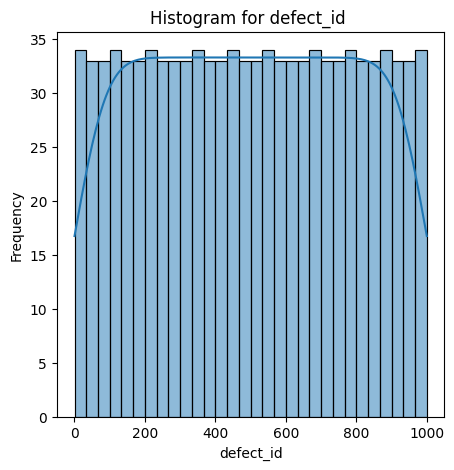

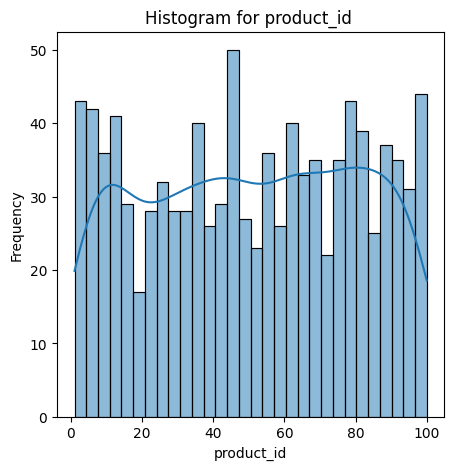

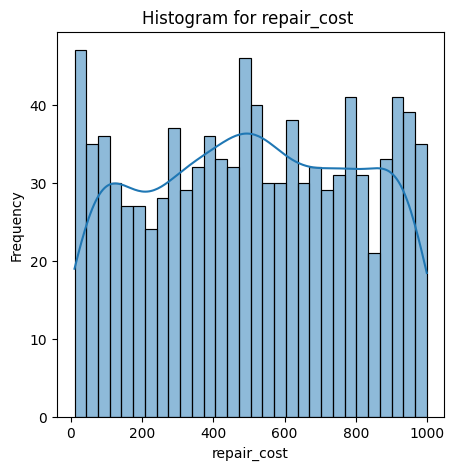

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(5,5))
    sns.histplot(df[col] , kde=True , bins=30)
    plt.title(f"Histogram for {col} ")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

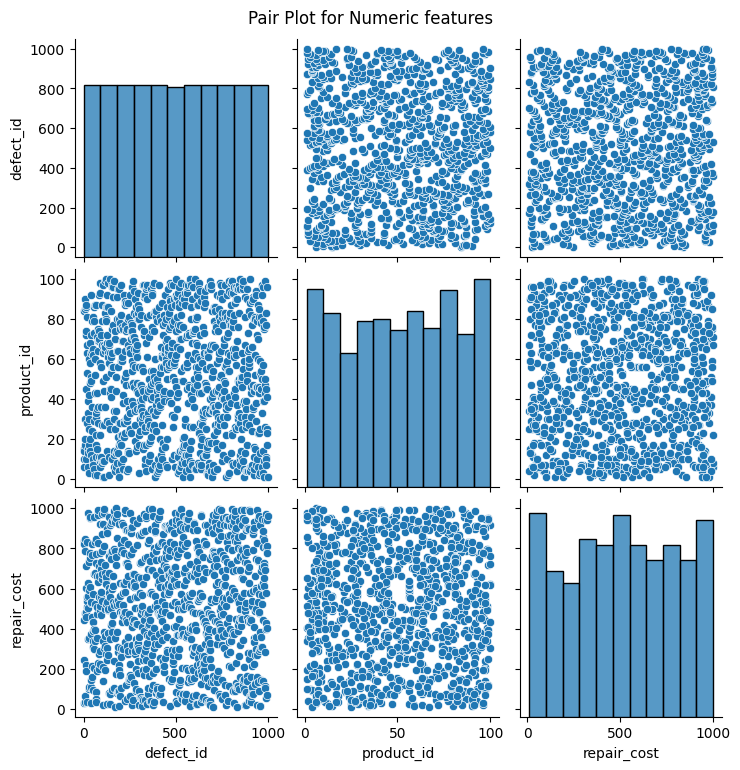

In [21]:
sns.pairplot(df[numeric_cols])
plt.suptitle('Pair Plot for Numeric features' , y=1.02)
plt.show()

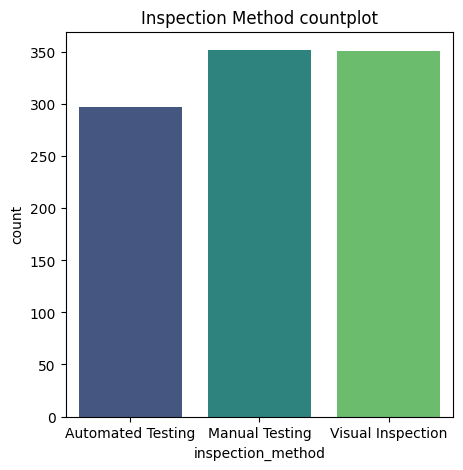

In [23]:
plt.figure(figsize=(5,5))
sns.countplot(x='inspection_method' , data=df , palette='viridis')
plt.title("Inspection Method countplot")
plt.show()

### FE

In [31]:
df.head()

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status,Year,Month,Day,Hour
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low,2024,1,1,0
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low,2024,1,1,0
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low,2024,1,1,0
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium,2024,1,1,0
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low,2024,1,1,0


In [30]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day

df["Hour"] = df["Timestamp"].dt.hour

In [32]:
df.drop(columns=["Timestamp","Machine_ID"] , inplace=True)

In [33]:
df.shape

(100000, 15)

In [35]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
df["Efficiency_Target"] = label_encoder.fit_transform(df["Efficiency_Status"])

In [47]:
label_encoder = LabelEncoder()
df["Operation_Mode"] = label_encoder.fit_transform(df["Operation_Mode"])

In [38]:
df["Efficiency_Status"].value_counts()

Efficiency_Status
Low       77825
Medium    19189
High       2986
Name: count, dtype: int64

In [39]:
df["Efficiency_Target"].value_counts()

Efficiency_Target
1    77825
2    19189
0     2986
Name: count, dtype: int64

In [40]:
df.columns

Index(['Operation_Mode', 'Temperature_C', 'Vibration_Hz',
       'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%',
       'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
       'Predictive_Maintenance_Score', 'Error_Rate_%', 'Efficiency_Status',
       'Year', 'Month', 'Day', 'Hour', 'Efficiency_Target'],
      dtype='object')

In [52]:
features = [
    'Operation_Mode', 'Temperature_C', 'Vibration_Hz',
       'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%',
       'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
       'Predictive_Maintenance_Score', 'Error_Rate_%','Year', 'Month', 'Day', 'Hour'
]

In [53]:
X = df[features]

In [54]:
y = df["Efficiency_Target"]

In [55]:
from sklearn.preprocessing import StandardScaler

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train , X_test , y_train , y_test = train_test_split(X_scaled,y, test_size=0.2 , random_state=42 , stratify=y)

In [60]:
from sklearn.linear_model import LogisticRegression

In [62]:
clf = LogisticRegression(random_state=42,max_iter=1000)
clf.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [63]:
y_pred = clf.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score , classification_report

In [65]:
accuracy_score(y_test,y_pred)

0.91655

In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       597
           1       0.95      0.96      0.95     15565
           2       0.80      0.76      0.78      3838

    accuracy                           0.92     20000
   macro avg       0.86      0.85      0.86     20000
weighted avg       0.91      0.92      0.92     20000



In [69]:
### Permutation imprtance

In [70]:
from sklearn.inspection import permutation_importance

In [71]:
result = permutation_importance(clf , X_test , y_test , n_repeats=10 , random_state=42 , n_jobs=-1)

In [73]:
importance_df = pd.DataFrame({
    'Feature' : features,
    'Importances' : result.importances_mean
})

In [75]:
importance_df.sort_values(by='Importances', ascending=False)

,Feature,Importances
9,Error_Rate_%,0.234895
7,Production_Speed_units_per_hr,0.117720
4,Network_Latency_ms,0.000235
6,Quality_Control_Defect_Rate_%,0.000150
3,Power_Consumption_kW,0.000150
13,Hour,0.000145
1,Temperature_C,0.000075
8,Predictive_Maintenance_Score,0.000015
2,Vibration_Hz,0.000005
10,Year,0.000000
